In [2]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

Question 1

Line parameters (a, b, c): 0.18896104236887284 -0.15926349508910098 -0.96898341760779


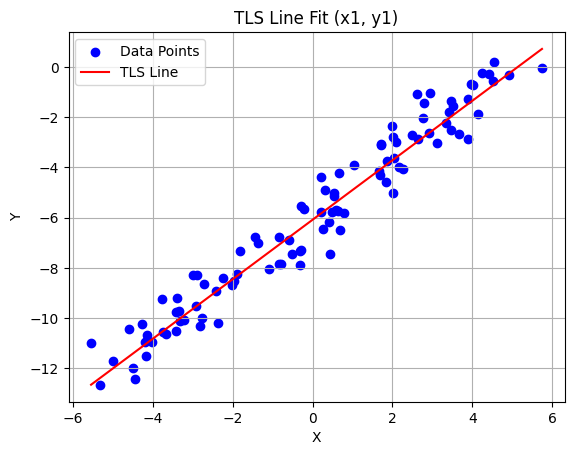

In [2]:
D = np.genfromtxt("csv/lines.csv", delimiter=",", skip_header=1)

x1 = D[:, 0]
y1 = D[:, 3]

# Build A matrix
A = np.column_stack((x1, y1, np.ones_like(x1)))

# SVD
U, S, Vt = np.linalg.svd(A)

# TLS solution is equivalent to the smallest singular vector of A
a, b, c = Vt[-1]

print("Line parameters (a, b, c):", a, b, c)

# ----------------------------------------
# Convert ax + by + c = 0 → y = mx + b
# ----------------------------------------
m = -a / b
intercept = -c / b

# Create x values for plotting line
x_vals = np.linspace(min(x1), max(x1), 100)
y_vals = m * x_vals + intercept

# ----------------------------------------
# Plot
# ----------------------------------------
plt.scatter(x1, y1, color='blue', label='Data Points')
plt.plot(x_vals, y_vals, color='red', label='TLS Line')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("TLS Line Fit (x1, y1)")
plt.legend()
plt.grid(True)
plt.show()

26 inliers found for line 1
23 inliers found for line 2
23 inliers found for line 3
Line 1: a=1.1803473205370607, b=2.77154244355646, c=-6.059703791099263
Line 2: a=2.2946755197954474, b=-2.3485649836860993, c=1.7745945973373367
Line 3: a=-4.168535444036682, b=2.750019827148103, c=18.45537203138827


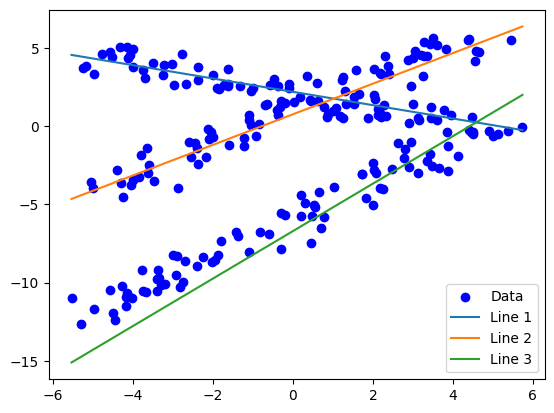

In [3]:
# Fix random seed so results are reproducible
np.random.seed(42)

# ---------------------------------------------
# Function to compute line parameters from 2 points
# Line is represented as: ax + by + c = 0
# ---------------------------------------------
def fit_line(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    
    a = y1 - y2
    b = x2 - x1
    c = x1*y2 - x2*y1
    
    return a, b, c

# ---------------------------------------------
# Function to compute perpendicular distance
# from points (x, y) to line ax + by + c = 0
# ---------------------------------------------
def distance(a, b, c, x, y):
    return np.abs(a*x + b*y + c) / np.sqrt(a*a + b*b)

# ---------------------------------------------
# RANSAC algorithm to find best line
# ---------------------------------------------
def ransac_line(X, Y, threshold=0.1, iterations=1000):
    best_inliers = []
    best_model = None
    
    n = len(X)
    
    for _ in range(iterations):
        # Step 1: randomly pick 2 points
        idx = np.random.choice(n, 2, replace=False)
        p1 = (X[idx[0]], Y[idx[0]])
        p2 = (X[idx[1]], Y[idx[1]])
        
        # Step 2: fit line through these 2 points
        a, b, c = fit_line(p1, p2)
        
        # Step 3: compute distance of ALL points to this line
        d = distance(a, b, c, X, Y)

        # Step 4: find inliers (consensus set)
        inliers = np.where(d < threshold)[0]
        
        # Step 5: keep the model with maximum inliers
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, c)
    
    return best_model, best_inliers

X_all = D[:, :3].flatten()
Y_all = D[:, 3:].flatten()

lines = []

# Loop to find 3 lines
for i in range(3):
    model, inliers = ransac_line(X_all, Y_all)
    lines.append(model)
    
    # mask the consensus set (inliers)
    mask = np.ones(len(X_all), dtype=bool)
    mask[inliers] = False
    
    X_all = X_all[mask]
    Y_all = Y_all[mask]

    print(len(inliers), "inliers found for line", i+1)

for i, (a, b, c) in enumerate(lines):
    print(f"Line {i+1}: a={float(a)}, b={float(b)}, c={float(c)}")

plt.scatter(X_all, Y_all, color='blue', label='Data')

x_vals = np.linspace(min(X_all), max(X_all), 100)

for i, (a, b, c) in enumerate(lines):
    m = -a / b
    intercept = -c / b
    
    plt.plot(x_vals, m * x_vals + intercept,
             label=f'Line {i+1}')

plt.legend()
plt.show()

Question 2

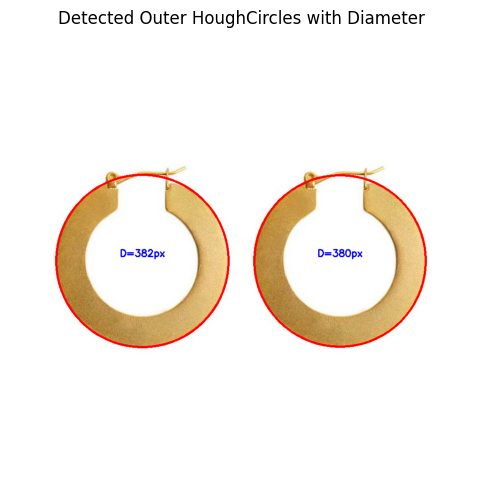

Earring 1: 7.52 cm
Earring 2: 7.56 cm


In [ ]:
img = cv.imread('a2_images/earrings.jpg')
output = img.copy()

# Convert to grayscale
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Blur to reduce noise
gray = cv.GaussianBlur(gray, (9, 9), 2)

# Detect circles
circles = cv.HoughCircles(
    gray,
    cv.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=100, # Adjust based on expected earring size
    maxRadius=200
)

if circles is not None:
    circles = np.uint16(np.around(circles[0]))

    selected = circles

    # Draw + print diameter
    for i, (x, y, r) in enumerate(selected, 1):
        diameter = 2 * r

        # Draw circle
        cv.circle(output, (x, y), r, (0, 0, 255), 3)

        # Draw diameter text
        cv.putText(output,
                    f"D={diameter}px",
                    (x - 50, y - 10),
                    cv.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 0, 0),
                    2)

output_rgb = cv.cvtColor(output, cv.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(output_rgb)
ax.set_title("Detected Outer HoughCircles with Diameter")
ax.axis('off')

plt.show()

FOCAL_LENGTH_MM = 8
DISTANCE_MM = 720
PIXEL_SIZE_MM = 0.0022  # 2.2 micrometers

# Magnification
m = FOCAL_LENGTH_MM / DISTANCE_MM

# Conversion factor
scale_factor = PIXEL_SIZE_MM / m

for i, (x, y, r) in enumerate(selected, 1):
    diameter_px = 2 * r
    diameter_mm = diameter_px * scale_factor

    print(f"Earring {i}: {diameter_mm/10:.2f} cm")


Question 3

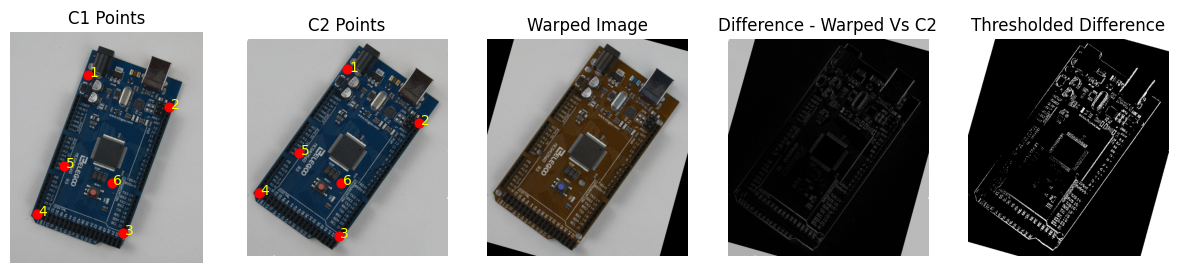

In [23]:
def show_selected_points(ax, image_bgr, points, title):
    # Convert BGR → RGB
    image_rgb = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB)

    # Show image
    ax.imshow(image_rgb)

    # Plot points
    for i in range(len(points)):
        ax.scatter(points[i][0], points[i][1], c='red', s=40)
        ax.text(points[i][0] + 5, points[i][1] + 5, str(i+1), color='yellow')

    ax.set_title(title)
    ax.axis('off')

fig, ax = plt.subplots(1, 5, figsize=(15, 3))

N = 6
global n
n = 0

p1 = np.empty((N, 2))
p2 = np.empty((N, 2))

DISPLAY_W, DISPLAY_H = 900, 650

# mouse callback function
def draw_circle(event, x, y, flags, param):
    global n
    p = param[0]
    if event == cv.EVENT_LBUTTONDOWN:
        cv.circle(param[1], (x, y), 5, (255, 0, 0), -1)
        p[n] = (x, y)
        n += 1

im1 = cv.imread('a2_images/c1.jpg', cv.IMREAD_REDUCED_COLOR_4)
im2 = cv.imread('a2_images/c2.jpg', cv.IMREAD_REDUCED_COLOR_4)

im1copy = im1.copy()
im2copy = im2.copy()

# ---------------------------------------------
# Capture image 1 points
# ---------------------------------------------
cv.namedWindow('Image 1', cv.WINDOW_AUTOSIZE)
param = [p1, im1copy]
cv.setMouseCallback('Image 1', draw_circle, param)

while (1):
    cv.imshow("Image 1", im1copy)
    if n == N:
        break
    if cv.waitKey(20) & 0xFF == 27:
        break

cv.destroyWindow("Image 1")
show_selected_points(ax[0], im1copy, p1[:n], "C1 Points")

param = [p2, im2copy]
n = 0

# ---------------------------------------------
# Capture image 2 points
# ---------------------------------------------
cv.namedWindow("Image 2", cv.WINDOW_AUTOSIZE)
cv.setMouseCallback('Image 2', draw_circle, param)

while (1):
    cv.imshow("Image 2", im2copy)
    if n == N:
        break
    if cv.waitKey(20) & 0xFF == 27:
        break

cv.destroyWindow("Image 2")
show_selected_points(ax[1], im2copy, p2[:n], "C2 Points")

# ---------------------------------------------
# Compute homography
# ---------------------------------------------
H, mask = cv.findHomography(p1, p2, cv.RANSAC)

# Warp image 1 to image 2 perspective
h, w = im2.shape[:2]
warped = cv.warpPerspective(im1, H, (w, h))

ax[2].imshow(warped)
ax[2].set_title("Warped Image")
ax[2].axis('off')

# Convert to grayscale (difference detection simpler, faster, and less noisy in single channel)
gray_warped = cv.cvtColor(warped, cv.COLOR_BGR2GRAY)
gray_im2 = cv.cvtColor(im2, cv.COLOR_BGR2GRAY)

# Pixel-by-pixel absolute difference
# Black (0)-> no difference, Gray-> small difference, White-> big difference
diff = cv.absdiff(gray_im2, gray_warped)

ax[3].imshow(diff, cmap='gray')
ax[3].set_title("Difference - Warped Vs C2")
ax[3].axis('off')

# Threshold (to highlight differences)
# If difference > 30 -> white (255) Else -> black (0)
_, diff_thresh = cv.threshold(diff, 30, 255, cv.THRESH_BINARY)

ax[4].imshow(diff_thresh, cmap='gray')
ax[4].set_title("Thresholded Difference")
ax[4].axis('off')

cv.waitKey(0)
cv.destroyAllWindows()